# Playground

In [7]:
ibeam_smart.getPower()

0.0

In [ ]:
# position as array or dict
position = {'x': 0, 'y': 0, 'z': 0}
poi_manager_logic.move_scanner(position)

## Get confocal image

In [15]:
import matplotlib.pyplot as plt
import numpy as np

In [31]:
scan_data = scanning_data_logic.get_current_scan_data()

In [32]:
source = 'APD1'

data = scan_data.data[source]
(xrange,yrange) = scan_data.scan_range

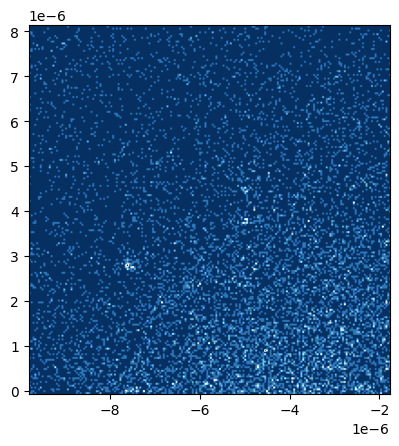

In [33]:
imgdata = np.fliplr(np.array(data)).transpose() # scudi displayes in a weird way.
extent=[xrange[0],xrange[1],yrange[0],yrange[1]]
plt.imshow(imgdata, extent=extent, cmap='RdBu_r')

## Vlads code to change resonant laser freq

In [12]:
ple_gui

<qudi.gui.ple.ple_gui.PLEScanGui(0x2b040b5c9b0) at 0x000002B041918580>

In [8]:
motordriver_pi3_remote.current_motor = 1

motordriver_pi3_remote.current_motor = 1
motordriver_pi3_remote.motor_position = 75

bad positions
55 to 75
135 to 150
300 to 335

In [52]:
motordriver_pi3_remote.motor_position = 75

In [13]:
scanner_gui

<qudi.gui.scanning.scannergui.ScannerGui(0x2b039f73e80) at 0x000002B037D4B780>

In [14]:
ws_wavemeter

<qudi.hardware.wavemeter.ws_wavemeter.HighFinesseWavemeter(0x1fbbf8203e0) at 0x000001FBC319F800>

In [15]:
scanning_probe_logic

<qudi.logic.scanning.probe_logic.ScanningProbeLogic(0x2b039f739a0) at 0x000002B036411B40>

In [1]:
wavelengthset_laser_offset

NameError: name 'wavelength' is not defined

In [2]:

# %%
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

def save_scan(name):
    scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
    scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
    dir_ = scanning_data_logic.module_default_data_dir
    return name, dir_

#to be rapaired:
def set_laser_offset(v):
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc._laser1.dl.pc.voltage_set.set(v)


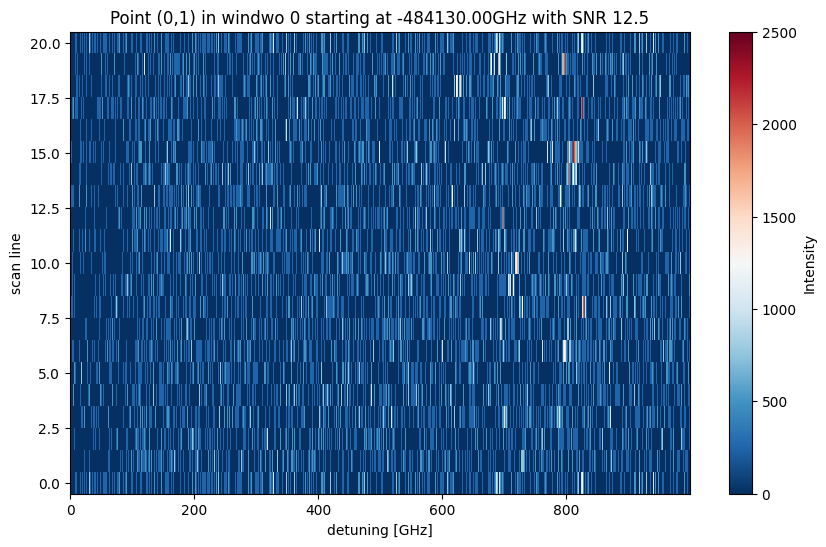

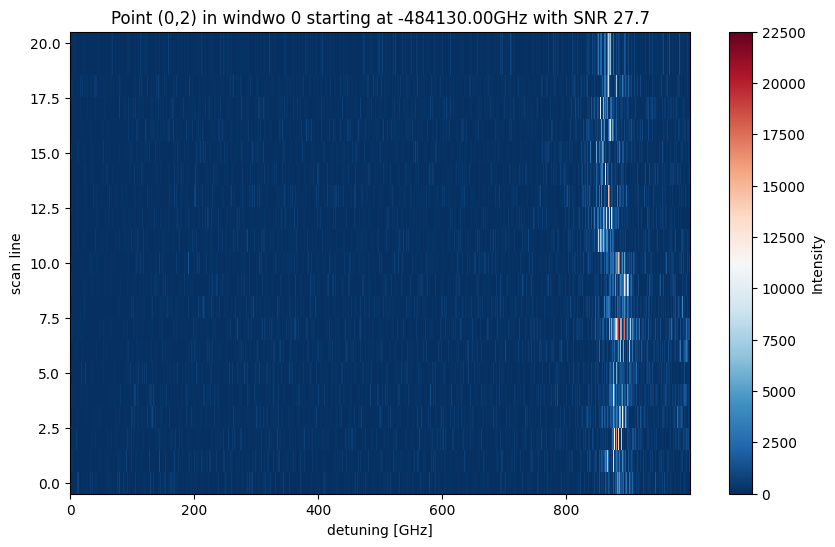

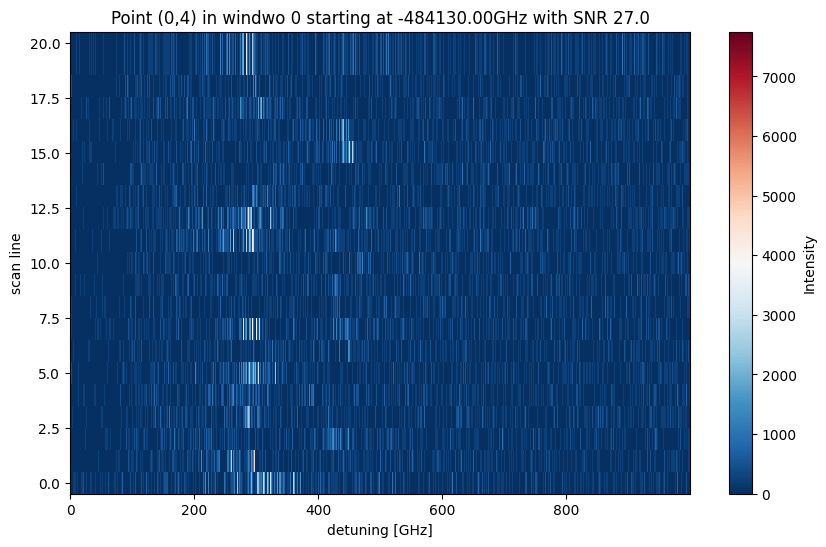

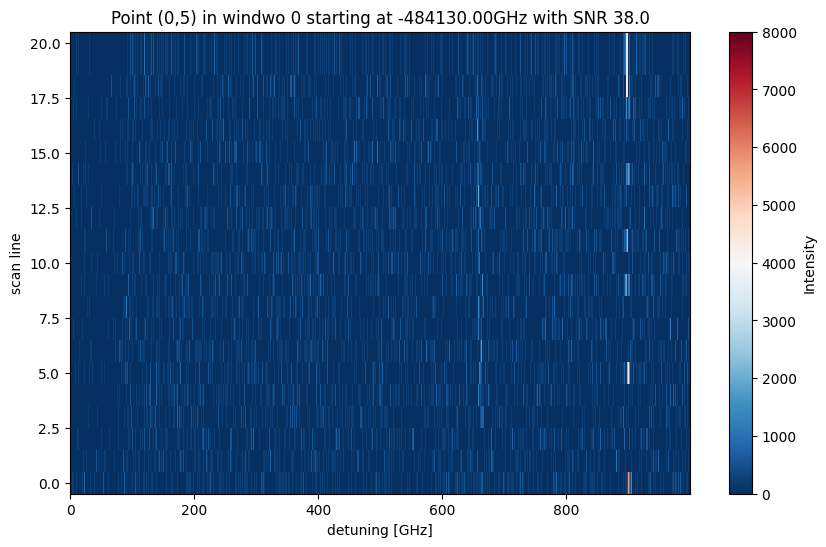

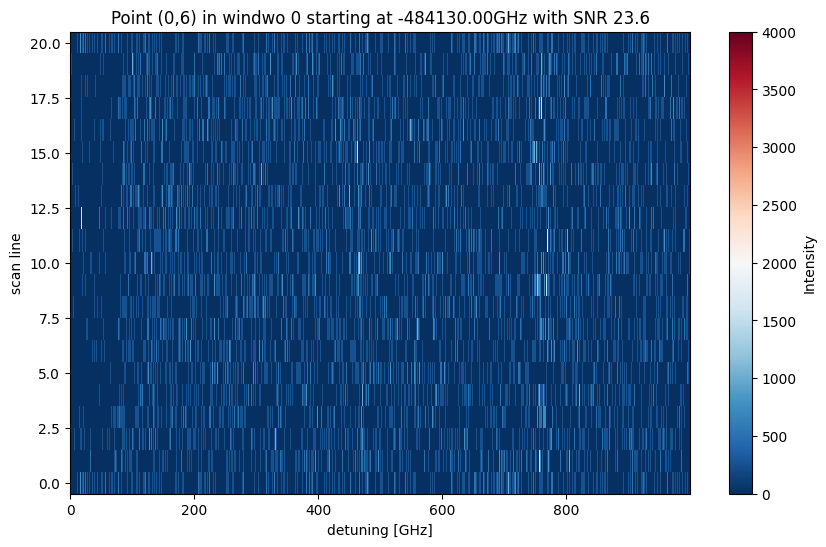

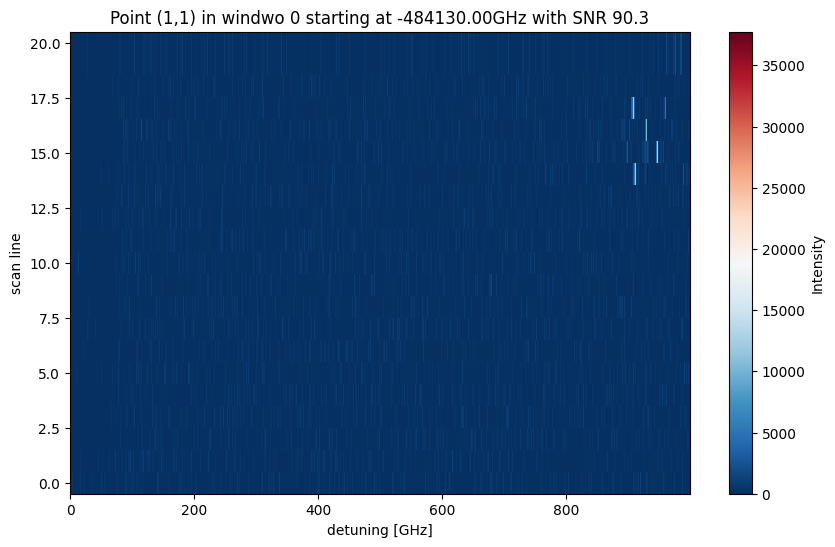

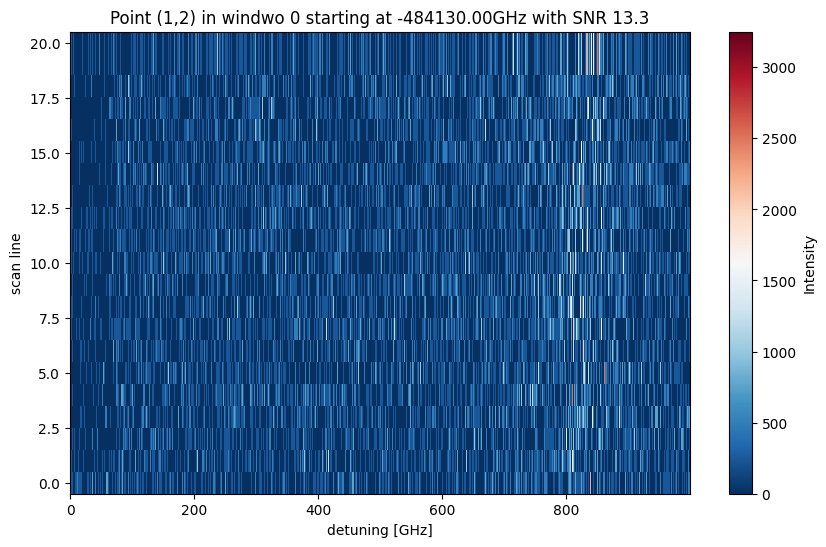

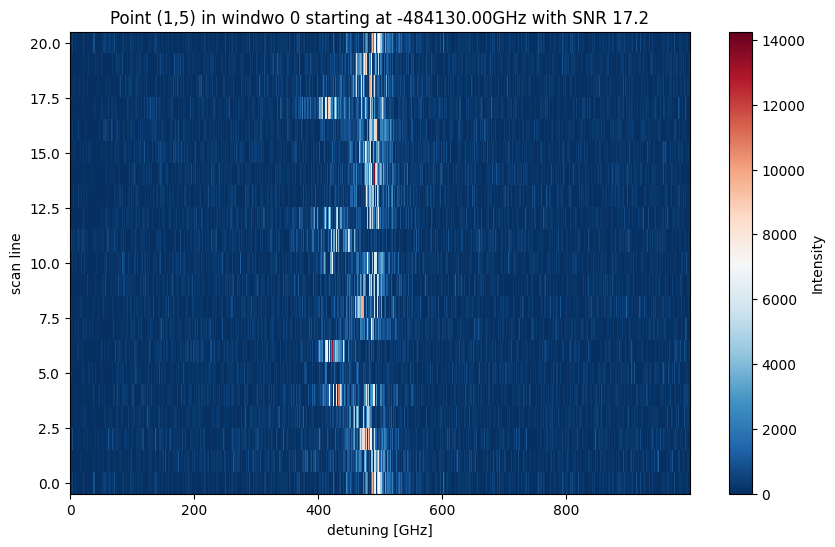

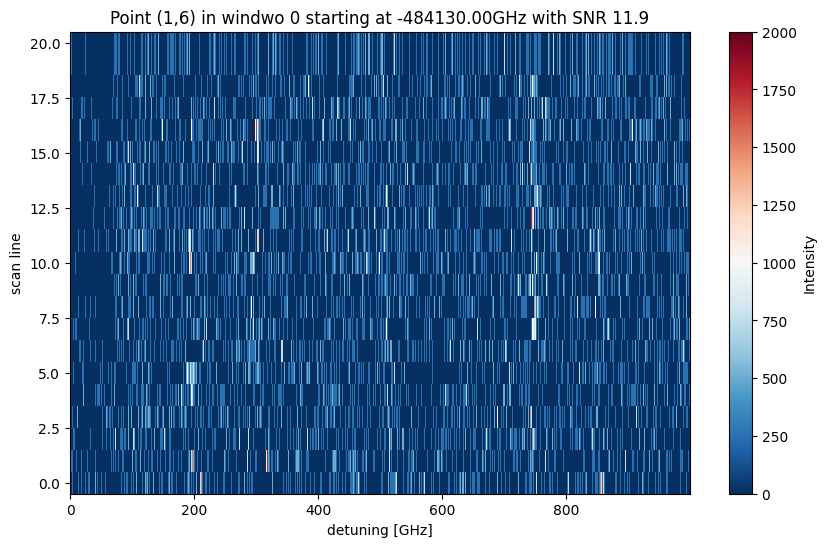

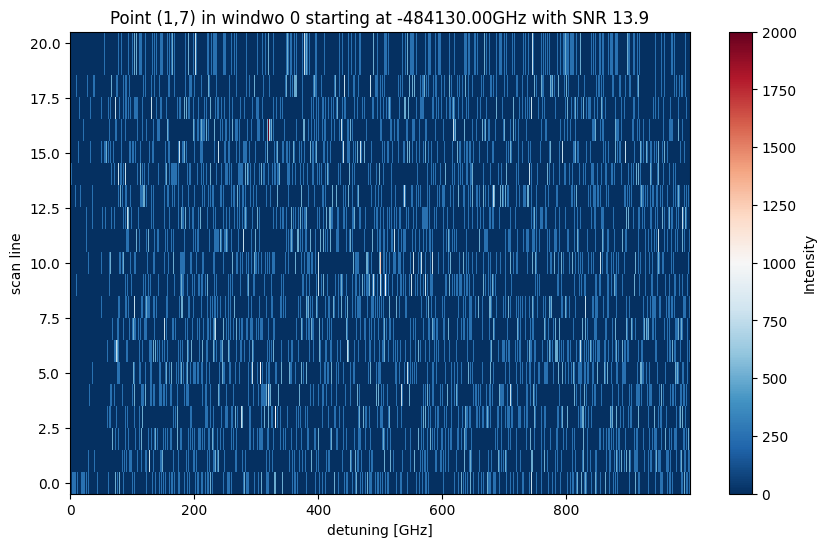

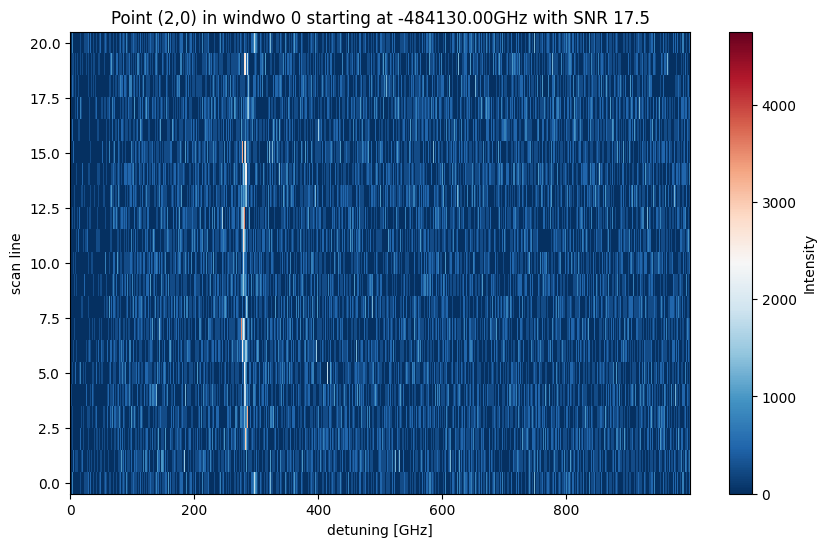

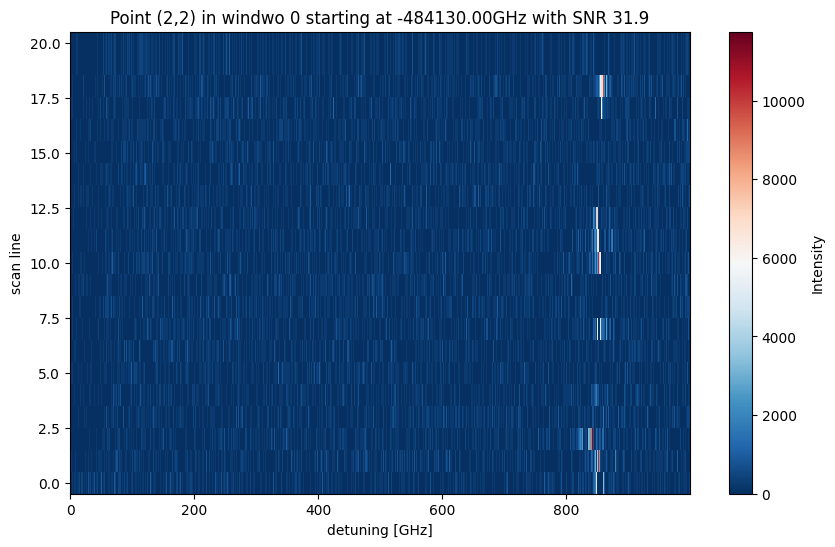

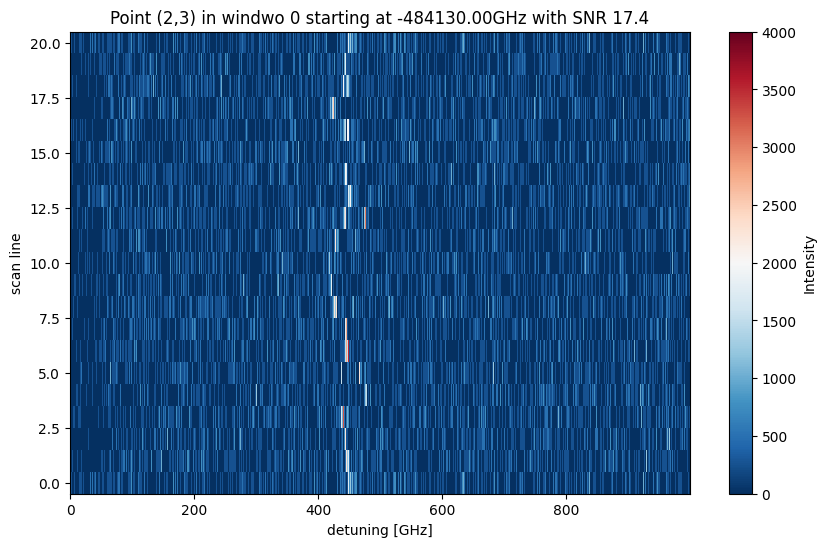

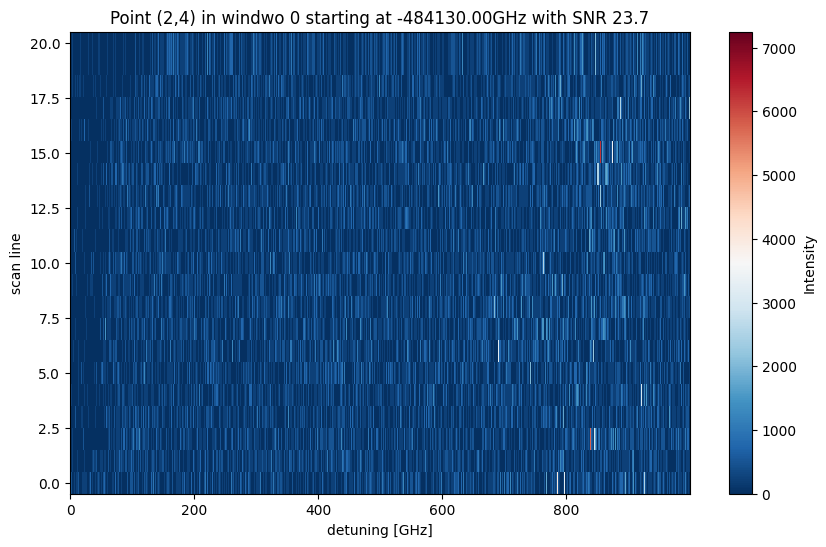

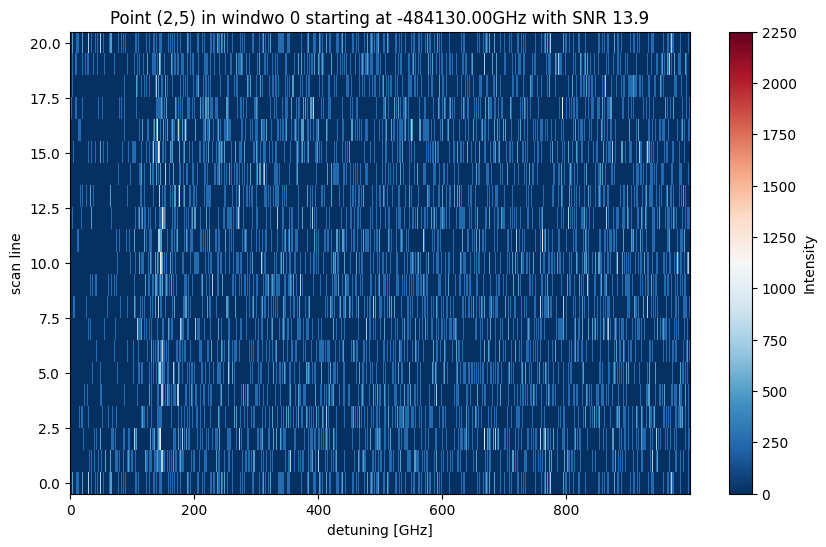

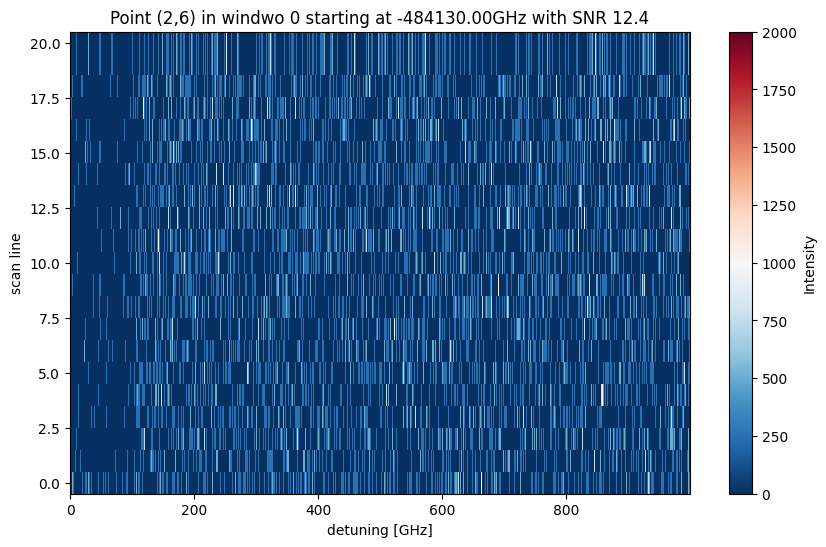

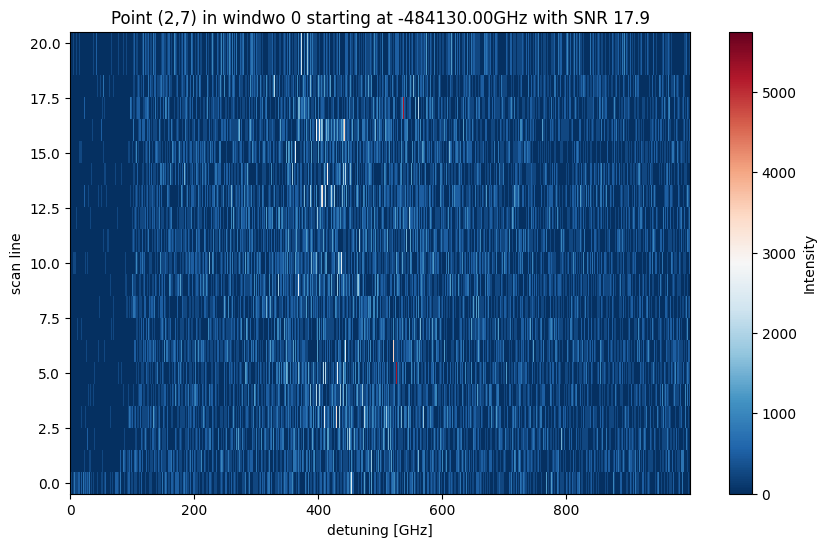

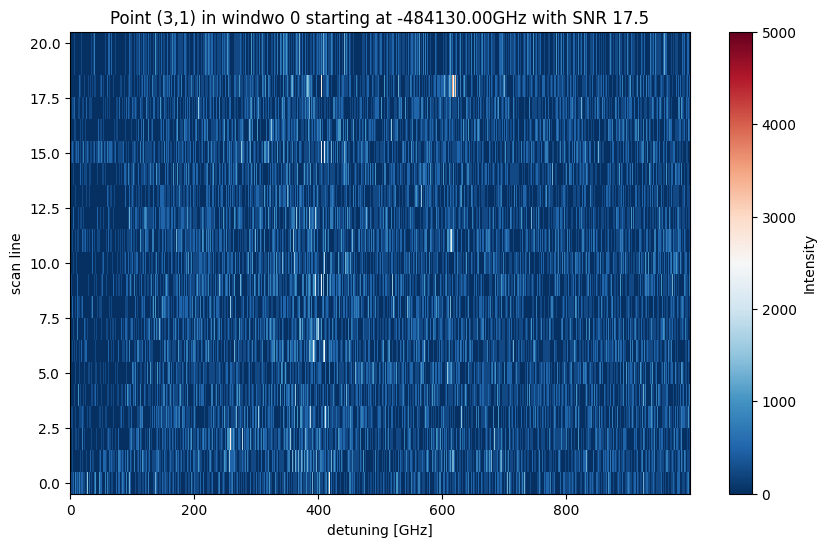

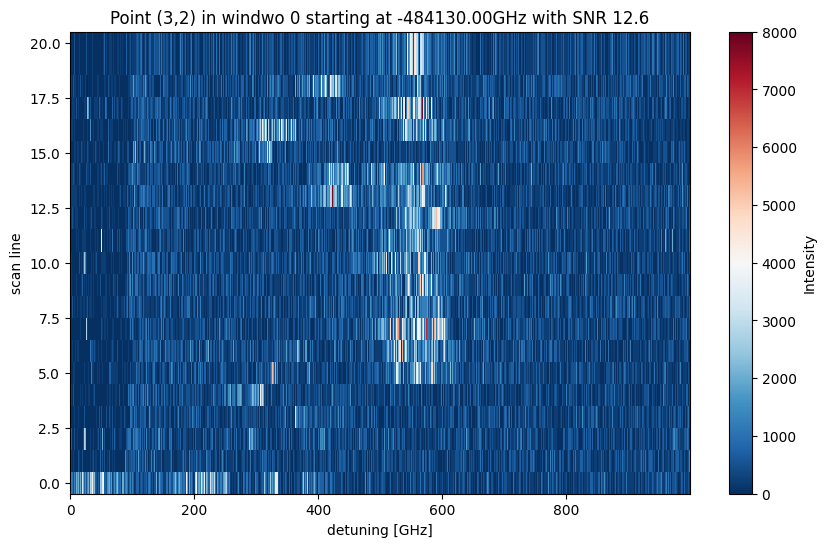

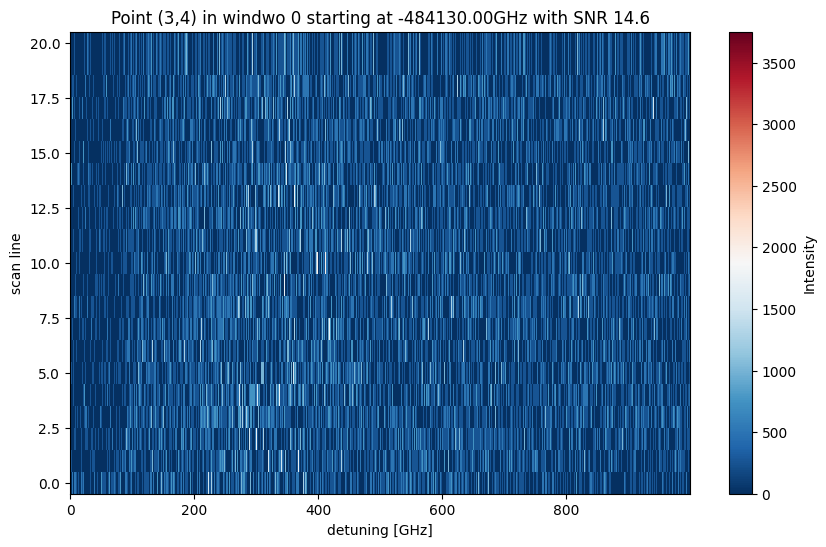

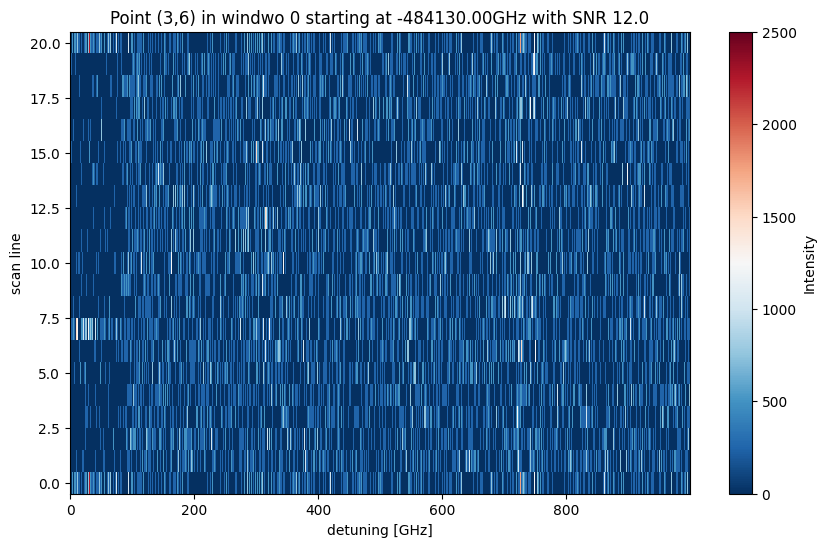

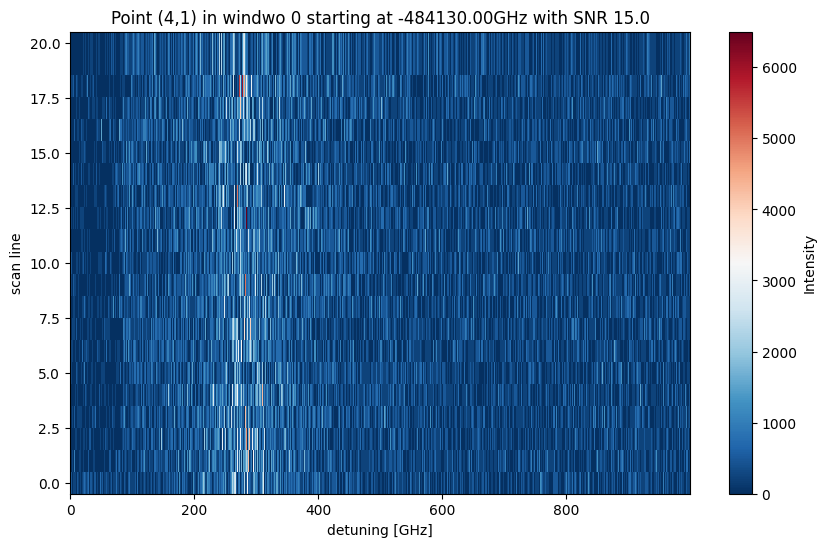

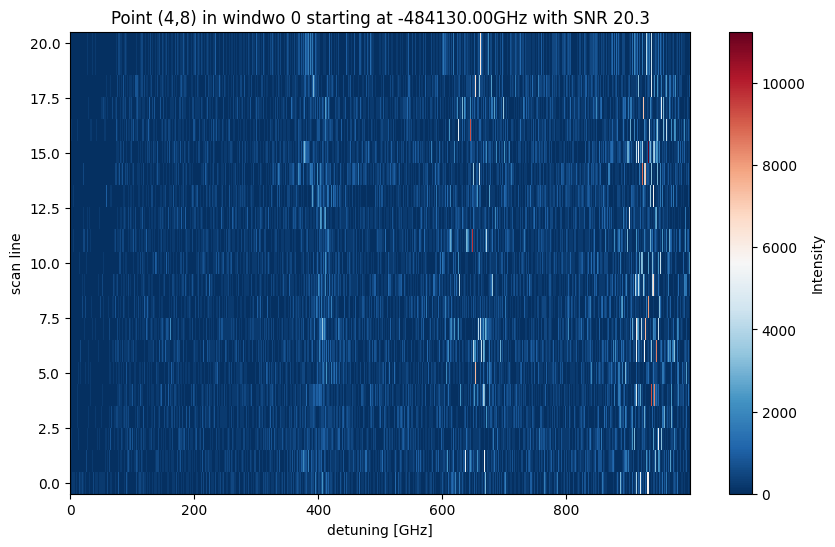

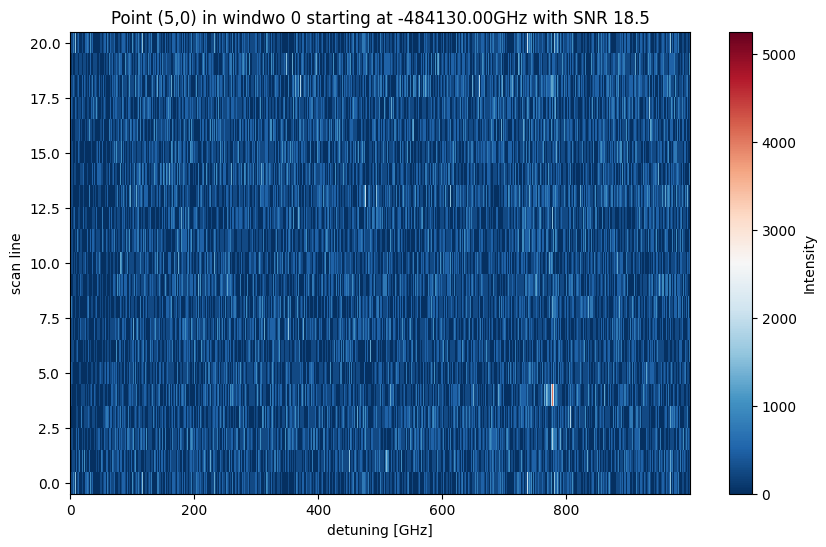

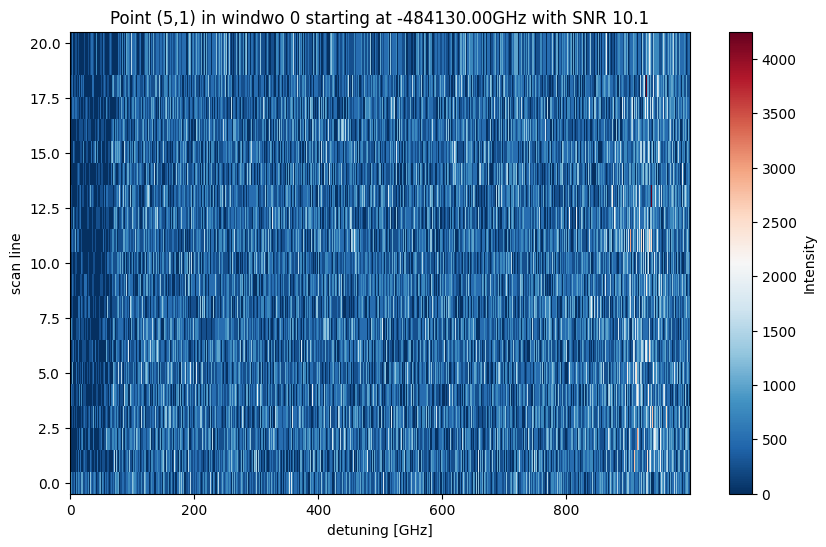

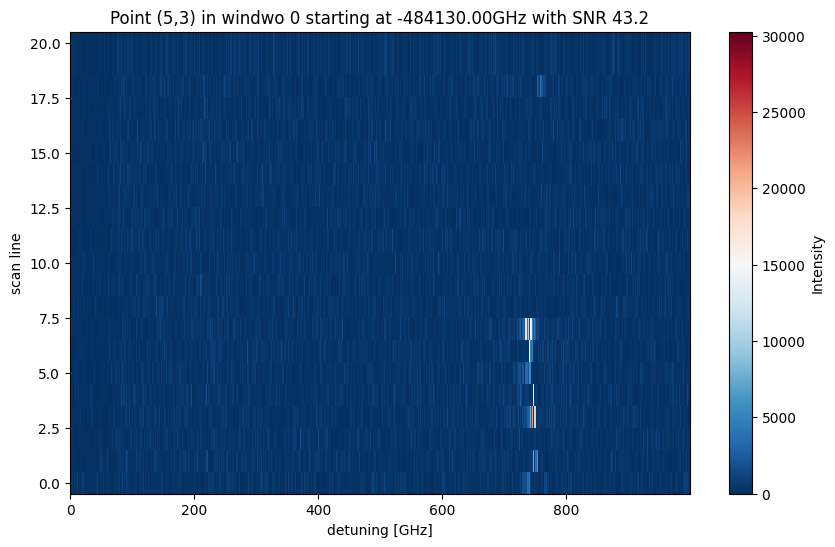

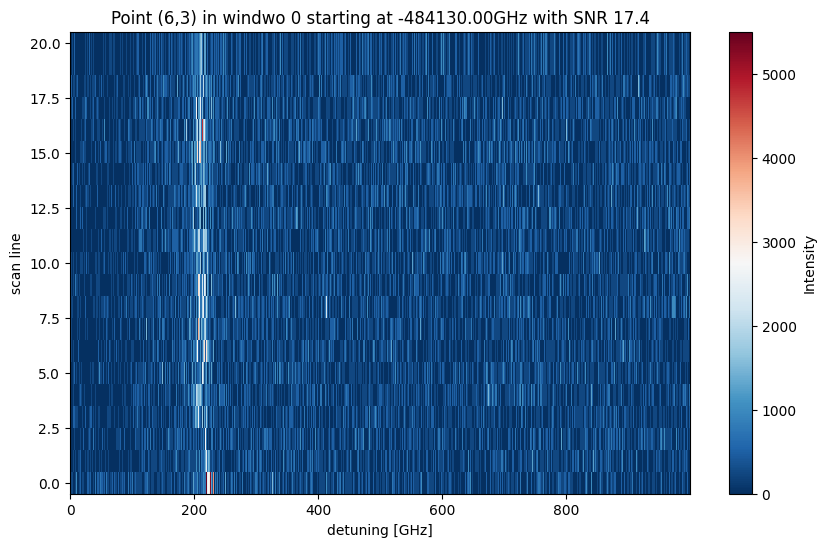

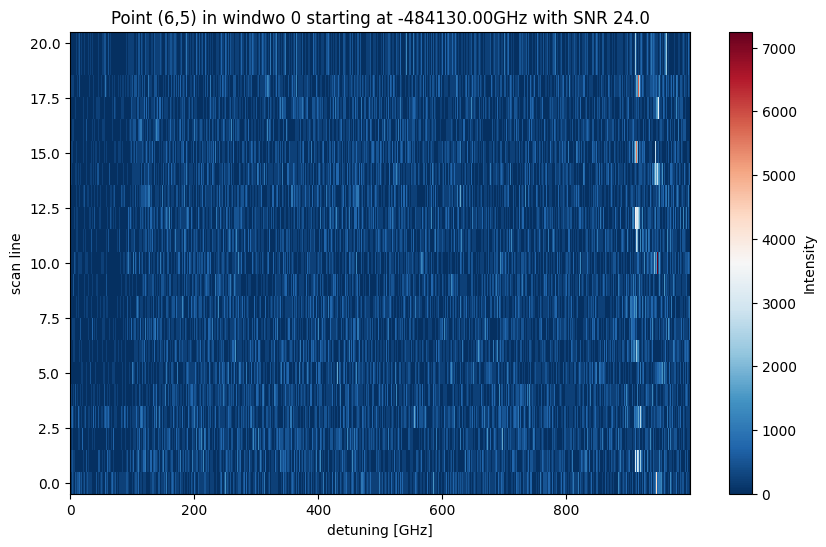

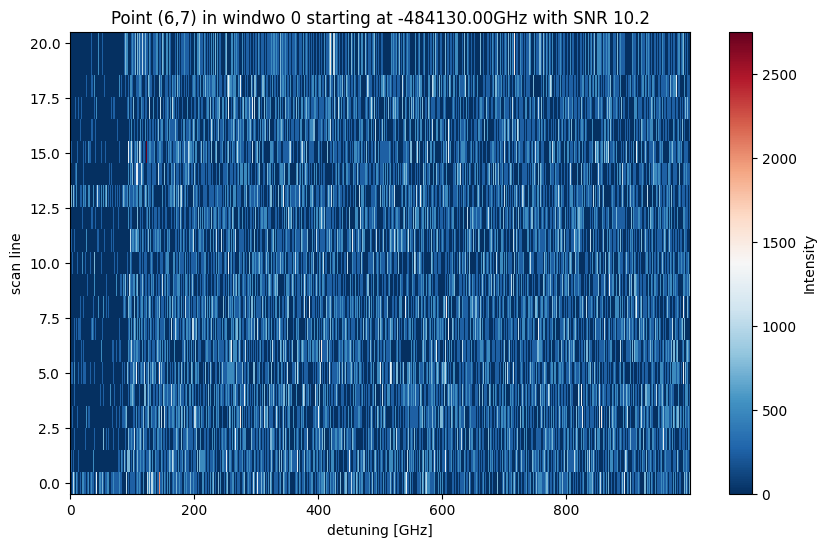

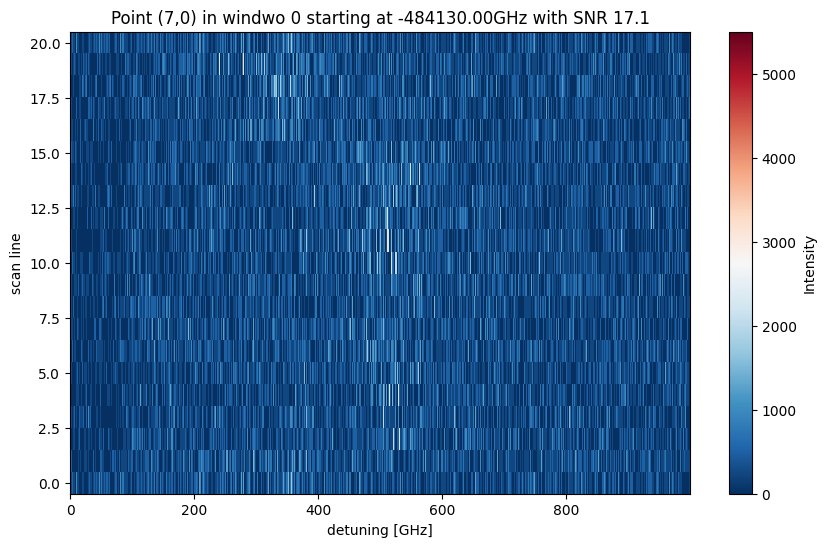

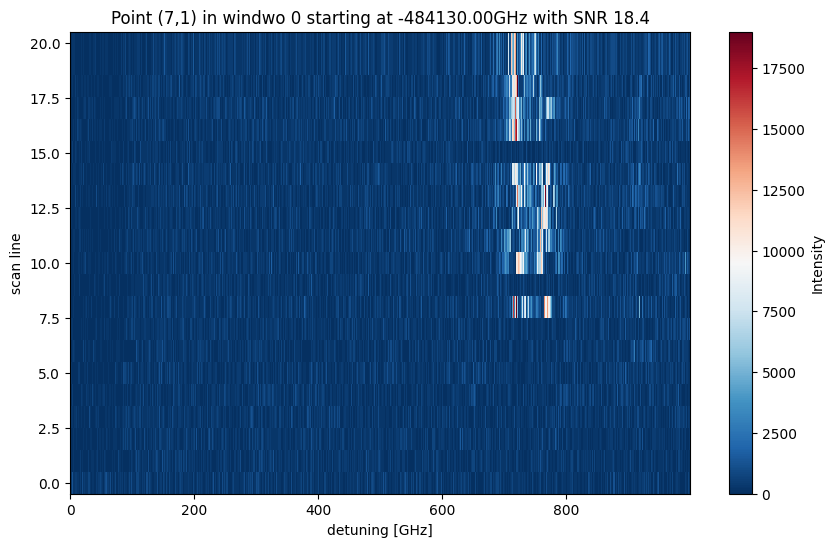

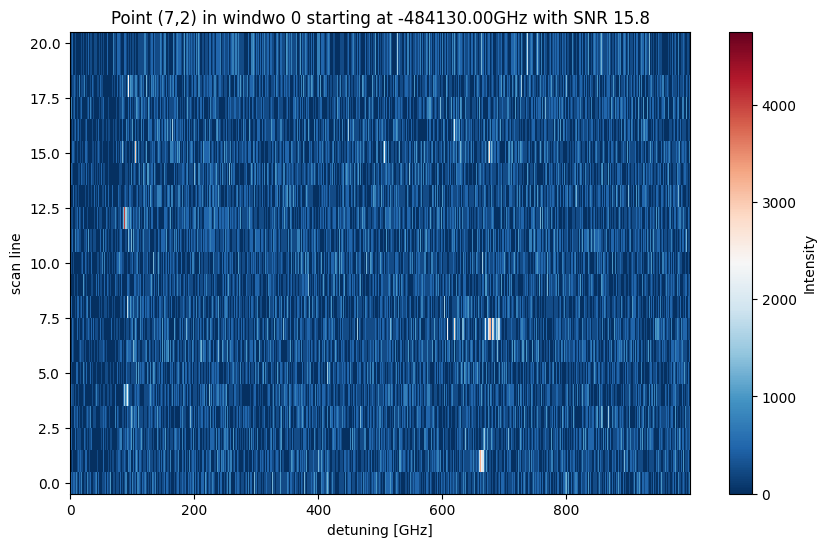

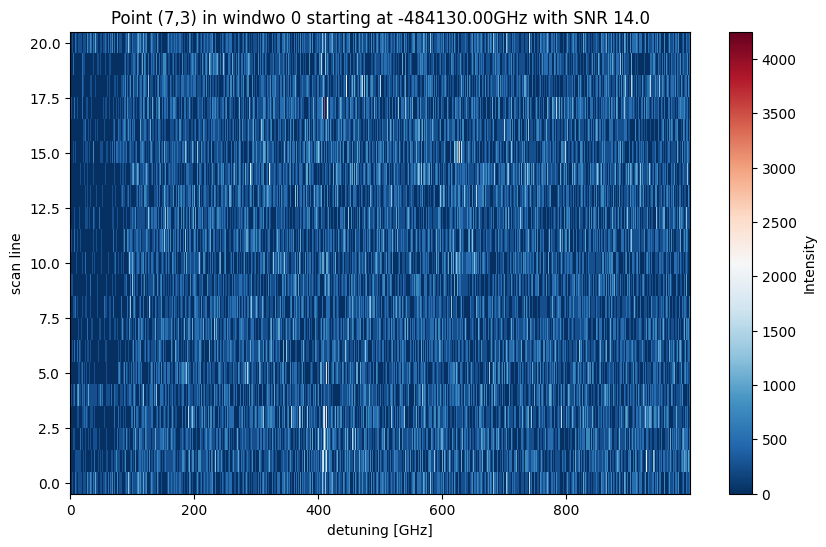

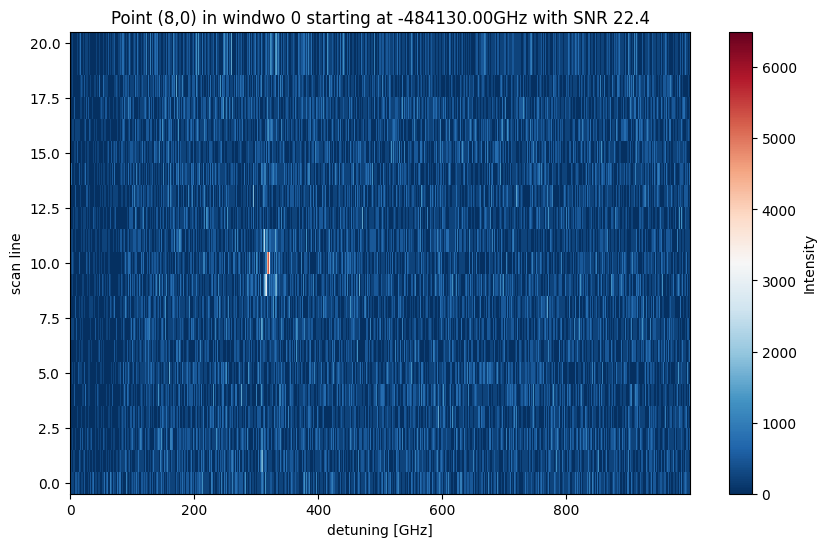

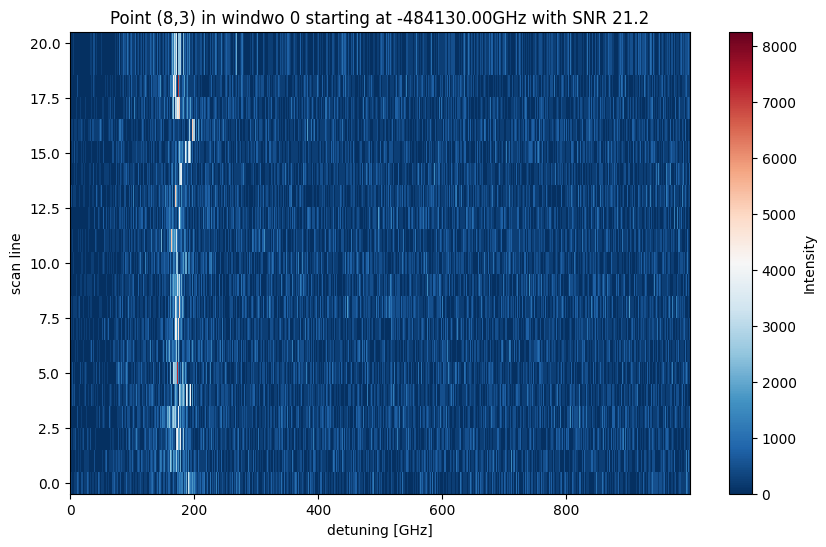

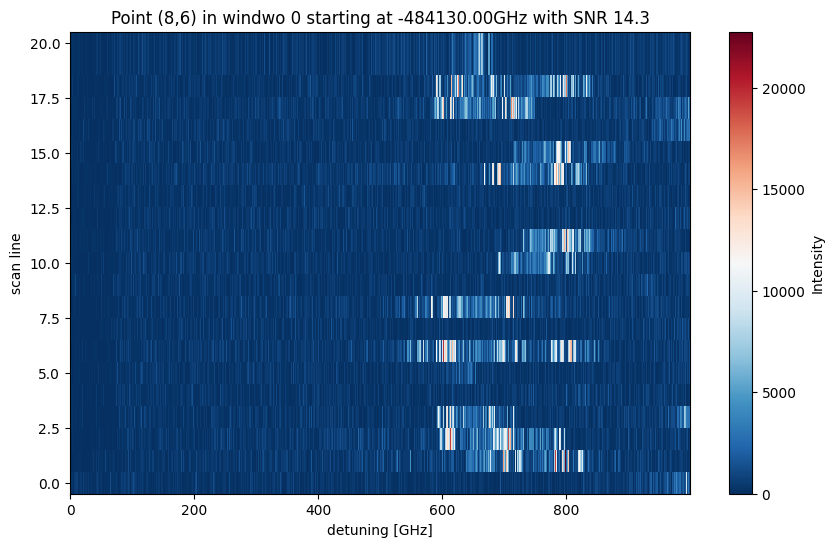

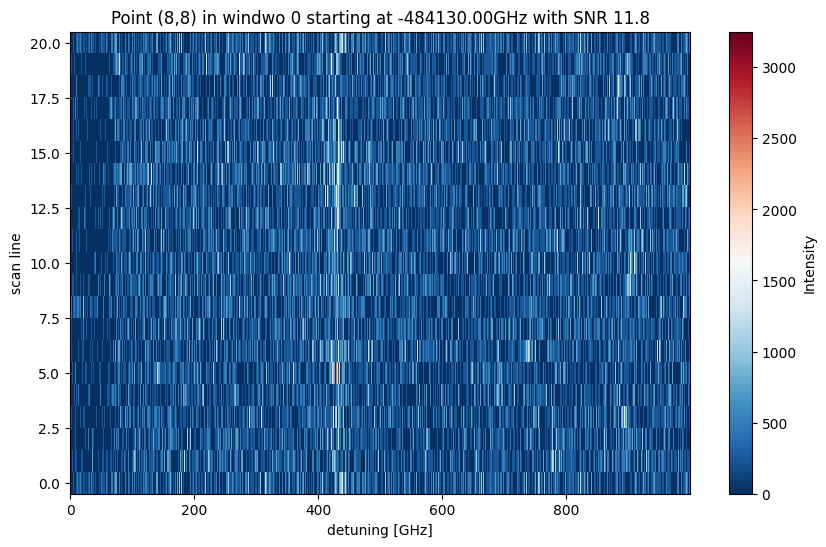

In [ ]:
plot_data_from_dict(data_signal0)

In [ ]:
motordriver_pi3.current_motor = 0

In [ ]:
ws_wavemeter.start_acquisition()
# %%
# Parameters
start_freq = 0  # GHz to Hz
end_freq = 18500  # GHz to Hz
step = 5000 #100  # GHz to Hz
num_steps = int((end_freq - start_freq) / step) + 1  # +1 for inclusive range
#resolution = (150, 150)  # x, y points

w0 = 484.130 #THz
# Data structure for results
frequencies = np.linspace(start_freq, end_freq, num_steps)

scan_names = {}
experiment_name = "resonant-confocal"
# Loop through frequencies
for i, freq in enumerate(frequencies):
    # Set laser frequency
    go_to_ple_target(freq)
    time.sleep(3)

    # Measure and record wavelength
    wavelength = (ws_wavemeter.get_current_wavelength() - w0) * 1e3   # to GHz
    print(wavelength)

    # Start scan and save data
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

# %%
ws_wavemeter.start_acquisition()
(ws_wavemeter.get_current_wavelength() - 484.130) * 1e3

# %%

# Process data (replace with your specific code)
# Here's an example using NumPy:
fluorescence_intensities = []
for data, _ in scan_data:
    # Assuming data is a 2D array of fluorescence intensities
    fluorescence_intensities.append(data.sum(axis=0))  # Sum along y-axis

# Create histograms (adapt binning as needed)
for i, intensity in enumerate(fluorescence_intensities):
    plt.hist(intensity, bins=50, label=f"{frequencies[i] / 1e9:.2f} GHz")

plt.xlabel("Fluorescence Intensity")
plt.ylabel("Count")
plt.title("Fluorescence Intensity at Different Frequencies")
plt.legend()
plt.show()


# Check offset between resonant and off resonant

In [8]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
def do_optimize_and_wait():
    scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    optimal_position = scanning_optimize_logic.optimal_position
    return optimal_position

def turn_on_green(power = 80e3):
    # 80e3 are 80mW
    ibeam_smart.setPower(power)

def turn_off_green():
    ibeam_smart.setPower(0)

In [4]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

# settings optimizer logic
settings = {
    'scan_frequency' : {'z': 5.0, 'x': 100.0, 'y': 100.0},
    'data_channel' : 'APD1',
    'scan_range' : {'z': 1.8e-06, 'x': 4e-07, 'y': 4e-07},
    'scan_resolution': {'z': 200, 'x': 25, 'y': 25},
    'scan_sequence': [('x', 'y'), 'z']
}
scanning_optimize_logic.set_optimize_settings(settings)

{'scan_frequency': {'z': 5.0, 'x': 100.0, 'y': 100.0}, 'data_channel': 'APD1', 'scan_range': {'z': 1.8e-06, 'x': 4e-07, 'y': 4e-07}, 'scan_resolution': {'z': 200, 'x': 25, 'y': 25}, 'scan_sequence': [('x', 'y'), ('z',)]}

In [7]:
coords_green = np.zeros(3)
coords_red = np.zeros(3)
for i in range(10):
    turn_on_green()
    _opt = do_optimize_and_wait()
    opt = np.array([float(_opt['x']),float(_opt['y']),float(_opt['z'])])
    coords_green = np.vstack((coords_green,opt))
    print('green')
    print(coords_green)
    turn_off_green()
    _opt = do_optimize_and_wait()
    opt = np.array([float(_opt['x']),float(_opt['y']),float(_opt['z'])])
    coords_red = np.vstack((coords_red,opt))
    print('red')
    print(coords_red)

green
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]]
red
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]]
green
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]
 [-1.59255033e-08 -5.40047549e-06  1.90974865e-06]]
red
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]
 [-9.45134653e-09 -5.40802166e-06  1.90073964e-06]]
green
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]
 [-1.59255033e-08 -5.40047549e-06  1.90974865e-06]
 [-1.11442618e-08 -5.40684737e-06  1.82952883e-06]]
red
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]
 [-9.45134653e-09 -5.40802166e-06  1.90073964e-06]
 [-2.62242350e-09 -5.40146280e-06  2.04124054e-06]]
green
[[ 0.00000000e+00  0.00000000e+00  0.000

In [ ]:
# coords_green = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
# [-1.81512691e-08 -5.39908669e-06  1.86106216e-06]
# [-1.59255033e-08 -5.40047549e-06  1.90974865e-06]
# [-1.11442618e-08 -5.40684737e-06  1.82952883e-06]
# [-2.05469319e-08 -5.38524593e-06  2.03309189e-06]
# [-1.90723863e-08 -5.38167088e-06  1.98445135e-06]
# [-2.19087487e-08 -5.37961598e-06  1.99794144e-06]
# [-7.76273520e-09 -5.36210570e-06  2.07177387e-06]
# [-1.69062759e-08 -5.37110687e-06  2.09605135e-06]
# [-3.51968970e-08 -5.33262472e-06  2.24019550e-06]
# [-3.19011560e-08 -5.33016759e-06  2.27804234e-06]]

# coords_red = [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
# [-1.25011166e-08 -5.40977794e-06  1.95209099e-06]
# [-9.45134653e-09 -5.40802166e-06  1.90073964e-06]
# [-2.62242350e-09 -5.40146280e-06  2.04124054e-06]
# [-2.39039374e-08 -5.38198267e-06  2.05201892e-06]
# [-1.37417728e-08 -5.38511219e-06  2.05747297e-06]
# [-4.45747457e-09 -5.36457887e-06  2.07627838e-06]
# [-1.58719099e-08 -5.36153447e-06  2.14474685e-06]
# [-1.76755453e-08 -5.34930733e-06  2.25370901e-06]
# [-3.56750859e-08 -5.33683790e-06  2.23569550e-06]
# [-4.18681824e-08 -5.32877437e-06  2.17263694e-06]]

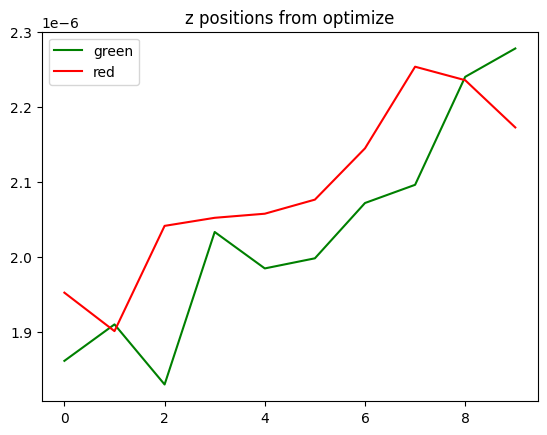

Text(0.5, 1.0, 'z red - z green, avg = 0.058474 um')

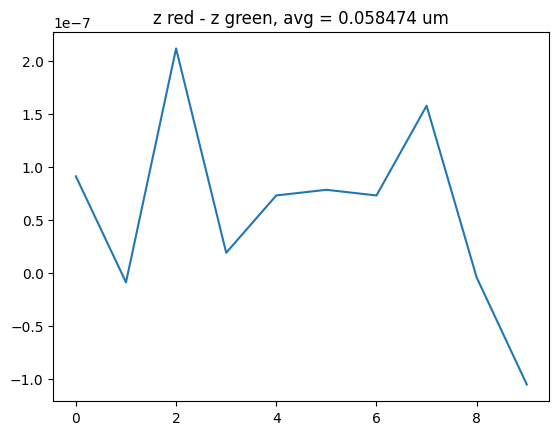

In [25]:
plt.plot(coords_green[1:,2],label='green', color='g')
plt.plot(coords_red[1:,2],label='red', color='r')
plt.legend()
plt.title('z positions from optimize')
plt.show()
plt.plot(coords_red[1:,2] - coords_green[1:,2])
plt.title('z red - z green, avg = %f um'%(1e6*np.mean(coords_red[1:,2] - coords_green[1:,2])))

# Check power dependence on detuning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro, NetworkConnection
import time

In [52]:
class testing_powerdepednence():
        def __init__(self):
                return
        
        def set_laser_offset(self, v):
                with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
                        dlc._laser1.dl.pc.voltage_set.set(v)
                return

        def start_power_channel(self):
                powermeter.set_activity_state('Power', True)
                return

        def stop_power_channel(self):
                powermeter.set_activity_state('Power', False)
                return

        def get_power(self):
                # in W
                power = powermeter.get_process_value('Power')
                power = power*1e6 # convert to uW
                return power

        def rotate_filterwheel(self, pos, limits=(105,175)):
                min_pos = limits[0]
                max_pos = limits[1]
                # roughly factor 3
                pos = min_pos if pos <= min_pos else pos
                pos = max_pos if pos >= max_pos else pos
                motordriver_pi3_remote.current_motor = 1
                motordriver_pi3_remote.motor_position = pos
                time.sleep(0.5)
                return pos
        
        def adjust_power(self, target_power, step_size=1, epsilon=0.5, limits_filterwheel=(105,175)):
                self.start_power_channel()
                actual_power = self.get_power()
                actual_posi = motordriver_pi3_remote.motor_position
                target_posi = actual_posi
                if actual_power >= target_power+epsilon:
                        # power too big, need to decrease power, need to increase angle
                        print('decreasing power')
                        step = abs(step_size)
                        while actual_power >= target_power+epsilon:
                                target_posi = target_posi +  step
                                print('moving to posi %.1f°'%target_posi)
                                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                                actual_power = self.get_power()
                                if actual_posi >= limits_filterwheel[1]-step_size:
                                        print('Reached lower limit of filterwheel position, power is %fuW'%actual_power)
                                        self.stop_power_channel()
                                        return actual_power
                        print('reached end.')
                        self.stop_power_channel()
                        return actual_power
                elif actual_power <= target_power-epsilon:
                        # power too small, need to increase power, need to decrease angle
                        print('increasing power')
                        step = -abs(step_size)
                        while actual_power <= target_power-epsilon:
                                target_posi = target_posi +  step
                                print('moving to posi %.1f°'%target_posi)
                                actual_posi = self.rotate_filterwheel(target_posi, limits=limits_filterwheel)
                                actual_power = self.get_power()
                                if actual_posi <= limits_filterwheel[0]+step_size:
                                        print('Reached upper limit of filterwheel position, power is %fuW'%actual_power)
                                        self.stop_power_channel()
                                        return actual_power
                        print('reached end.')
                        self.stop_power_channel()
                        return actual_power
                else:
                        print('power was fine')
                        self.stop_power_channel()
                        return actual_power
        
        def get_detuning(self, w0=484.13):
                """w0 in THz"""
                print('asking wavemeter for wavelength')
                current_wl = ws_wavemeter.get_current_wavelength()
                if np.isclose(current_wl,0,atol=10):
                        print('Could not get detuning, repeating in 10s')
                        time.sleep(10)
                        current_wl = ws_wavemeter.get_current_wavelength()
                wavelength = (current_wl - w0) * 1e3   # to GHz
                print('got wavelength')
                return wavelength
        
tester = testing_powerdepednence()

In [85]:
n_points = 10
voltages = np.linspace(5, 135, n_points)
print(voltages)

powers = np.zeros(n_points)
detunings = np.zeros(n_points)

tester.start_power_channel()
for i, voltage in enumerate(voltages):
    tester.set_laser_offset(voltage)
    time.sleep(10)
    detuning = tester.get_detuning()
    power = tester.get_power()
    detunings[i] = detuning
    powers[i] = power
tester.stop_power_channel()

[  5.          19.44444444  33.88888889  48.33333333  62.77777778
  77.22222222  91.66666667 106.11111111 120.55555556 135.        ]
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength


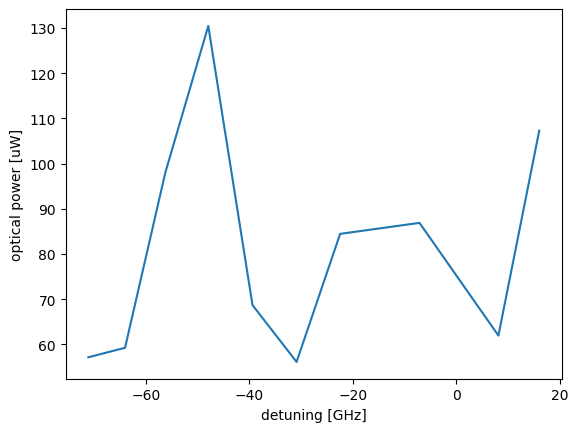

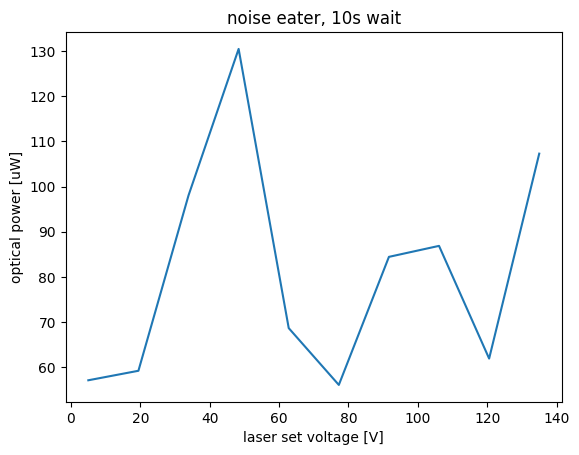

In [86]:
plt.plot(detunings, powers)
plt.xlabel('detuning [GHz]')
plt.ylabel('optical power [uW]')
plt.show()

plt.plot(voltages, powers)
plt.xlabel('laser set voltage [V]')
plt.ylabel('optical power [uW]')
plt.title('noise eater, 10s wait')
plt.show()

In [28]:
limits_filterwheel = [1,359]
posis = np.linspace(limits_filterwheel[0], limits_filterwheel[1], 360)
powers = np.zeros(len(posis))
for i, posi in enumerate(posis):
    a = tester.rotate_filterwheel(posi)
    tester.start_power_channel()
    power = tester.get_power()
    tester.stop_power_channel()
    powers[i] = power

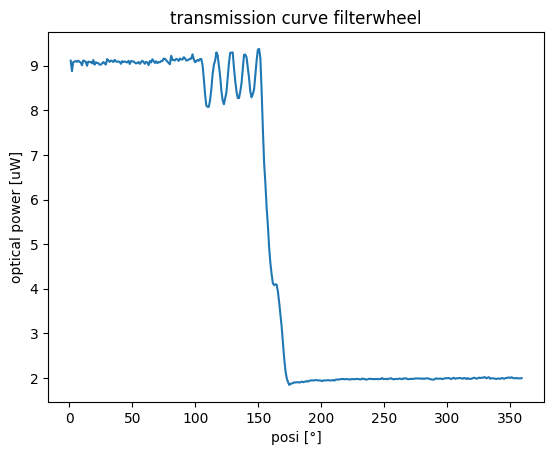

In [29]:
plt.plot(posis, powers)
plt.title('transmission curve filterwheel')
plt.xlabel('posi [°]')
plt.ylabel('optical power [uW]')
plt.show()

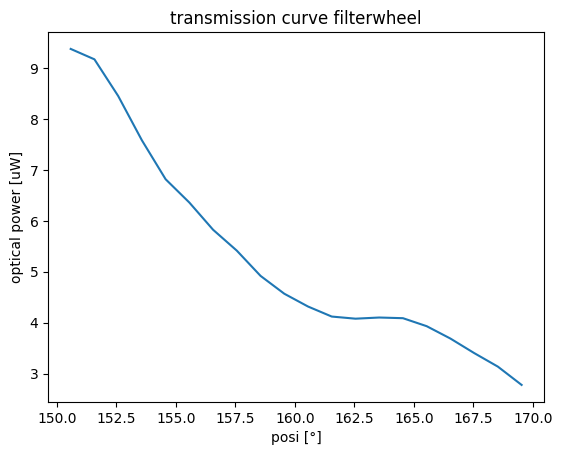

In [41]:
anf,end = 150,170
_posis = posis[anf:end]
_powers = powers[anf:end]
plt.plot(_posis, _powers)
plt.title('transmission curve filterwheel')
plt.xlabel('posi [°]')
plt.ylabel('optical power [uW]')
plt.show()

In [48]:
powers = []
tester.start_power_channel()
for i in range(30):
    power = tester.get_power()
    powers.append(power)
    time.sleep(1)
tester.stop_power_channel()

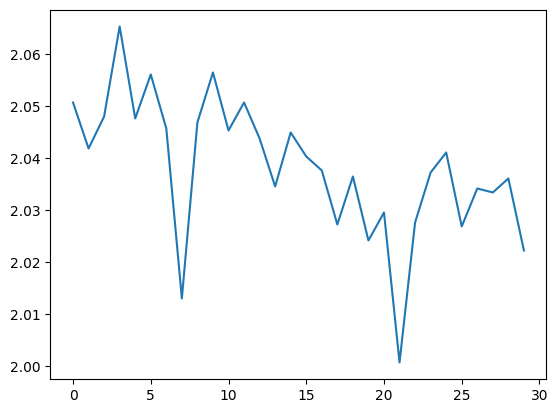

In [49]:
plt.plot(powers)
plt.show()

In [50]:
n_points = 5
voltages = np.linspace(100, 135, n_points)
target_power = 8.2
print(voltages)

powers = np.zeros(n_points)
powers_adjusted = np.zeros(n_points)
detunings = np.zeros(n_points)


for i, voltage in enumerate(voltages):
    tester.set_laser_offset(voltage)
    time.sleep(2)
    detuning = tester.get_detuning()
    power_adjusted = tester.adjust_power(target_power, step_size = 1, epsilon=0.2, limits_filterwheel=[150,170])
    tester.start_power_channel()
    power = tester.get_power()
    tester.stop_power_channel()
    detunings[i] = detuning
    powers[i] = power
    powers_adjusted[i] = power_adjusted


[100.   108.75 117.5  126.25 135.  ]
asking wavemeter for wavelength
got wavelength
increasing power
moving to posi 174.0°
moving to posi 173.0°
moving to posi 172.0°
moving to posi 171.0°
moving to posi 170.0°
moving to posi 169.0°
moving to posi 168.0°
moving to posi 167.0°
moving to posi 166.0°
moving to posi 165.0°
moving to posi 164.0°
moving to posi 163.0°
moving to posi 162.0°
moving to posi 161.0°
moving to posi 160.0°
moving to posi 159.0°
moving to posi 158.0°
moving to posi 157.0°
moving to posi 156.0°
moving to posi 155.0°
moving to posi 154.0°
moving to posi 153.0°
moving to posi 152.0°
moving to posi 151.0°
Reached upper limit of filterwheel position, power is 4.540537uW
asking wavemeter for wavelength
got wavelength
increasing power
moving to posi 150.0°
Reached upper limit of filterwheel position, power is 4.759488uW
asking wavemeter for wavelength
got wavelength
increasing power
moving to posi 149.0°
Reached upper limit of filterwheel position, power is 4.839667uW
aski

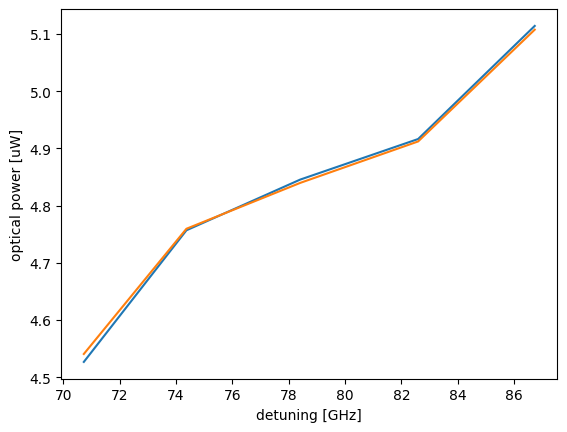

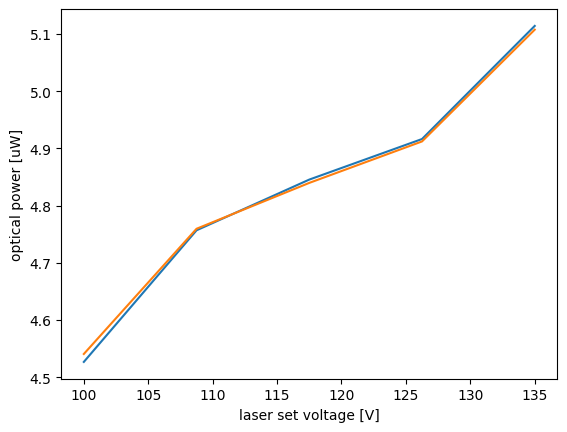

In [51]:
plt.plot(detunings, powers)
plt.plot(detunings, powers_adjusted)
plt.xlabel('detuning [GHz]')
plt.ylabel('optical power [uW]')
plt.show()

plt.plot(voltages, powers)
plt.plot(voltages, powers_adjusted)
plt.xlabel('laser set voltage [V]')
plt.ylabel('optical power [uW]')
plt.show()

In [60]:
tester.rotate_filterwheel(160)

160

## random

In [3]:
scanning_probe_logic
ibeam_smart

<qudi.hardware.laser.ibeam_smart.iBeamSmart(0x28488ba4890) at 0x0000028488817180>

In [4]:
def turn_on_green(power = 80e3):
    # 80e3 are 80mW
    ibeam_smart.setPower(power)

def turn_off_green():
    ibeam_smart.setPower(0)

In [5]:
turn_on_green()

In [ ]:
# bleaching

do_opt = True

def do_optimize_and_wait():
    scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    optimal_position = scanning_optimize_logic.optimal_position
    return optimal_position

import time

if do_opt:
    opt = do_optimize_and_wait()

for i in range(999):
    print(i)

    if do_opt:
        poi_manager_logic.move_scanner(opt)
        opt = do_optimize_and_wait()
    
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


## Change power

## Scan

<span style="color:red; font-size:40px">
Remember to disable updates before starting the measurement!
</span>

Both in Attodry, as well as in Wavemeter-PC.

Turn on red laser (Amplifier) before starting. Also lock it, but this should be on.

Set resolution to 250px. Adjust window to 10x10um, look for exact coords in old scans (e.g. step 1)

In [1]:
import time
import numpy as np
import json
import os
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro,LaserHead,  NetworkConnection, DeviceNotFoundError
import re
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import norm
import logging

In [2]:
scanner_gui ##
scanning_data_logic
poi_manager_logic ##
scanning_optimize_logic
ibeam_smart ##
ws_wavemeter ##
scanning_probe_logic
dl_pro ##
powermeter ##

<qudi.hardware.powermeter.thorlabs_powermeter.ThorlabsPowermeter(0x157908b35d0) at 0x00000157F17BDF40>

In [18]:
class change_optical_power():
    def __init__(self):
        return
    
    def get_bad_positions(self, offset):
        """Filterwheel is cracked at certain spots. 
        first number is beginning, last number is end of bad spot (all in gedree).
        """
        # initial_bad_positions = np.array([[55, 75], [135, 150], [300, 335]])
        initial_bad_positions = np.array([[0,1], [2,3]])
        bad_positions = initial_bad_positions + offset
        bad_positions = bad_positions%360
        bad_positions = list(bad_positions)
        return bad_positions
    
    def find_range(self, number, ranges):
        for rng in ranges:
            # convert necessary. Otherwise weird error.
            lower = float(rng[0])
            upper = float(rng[1])
            number = float(number)
            if (lower <= number <= upper):
                return True, [rng[0], rng[1]]
        return False, [0,0]

    def rotate_filterwheel(self, pos):
        motordriver_pi3_remote.current_motor = 1
        motordriver_pi3_remote.motor_position = pos
        time.sleep(0.5)
        return 
    
    def adjust_power(self, target_pwr, step_size=5, epsilon=2):
        """pwr in uW
        """
        # TODO: fix problem if bad range goes over 360, e.g. 355:5
        offset = 0

        num_steps = 0
        max_num_steps = abs(int(360/step_size)) + 5
        self._start_power_channel()
        current_posi = motordriver_pi3_remote.motor_position
        target_posi = current_posi
        current_pwr = self._get_power()
        # need to increase power (decrease angle)
        if target_pwr > current_pwr-epsilon:
            # print('case1: increase power')
            step = -abs(step_size)
            while target_pwr-epsilon > current_pwr:
                num_steps += 1
                if num_steps > max_num_steps:
                    print('Could not reach desired power. Giving up.')
                    self._stop_power_channel()
                    return current_pwr
                target_posi = (target_posi + step)%360
                print('current power = %.2fuW'%current_pwr)
                print('target posi = %d°'%target_posi)
                bad_posis = self.get_bad_positions(offset = offset)
                is_in_range, _range = self.find_range(target_posi, bad_posis)
                # target position lies in bad range
                if is_in_range:
                    self.rotate_filterwheel(_range[0])
                    power_beginning_bad_spot = self._get_power()
                    self.rotate_filterwheel(_range[1])
                    power_end_bad_spot = self._get_power()
                    # target power lies in bad range
                    if power_end_bad_spot <= target_pwr <= power_beginning_bad_spot:
                        # go to nearest edge
                        distances = np.abs(np.array([power_beginning_bad_spot, power_end_bad_spot]) - target_pwr)
                        if distances[0] > distances[1]:
                            target_posi = _range[1]
                        else:
                            target_posi = _range[0]
                        self.rotate_filterwheel(target_posi)
                        current_power = self._get_power()
                        self._stop_power_channel()
                        return current_power
                    # target power outside (bigger) bad range
                    else:
                        self.rotate_filterwheel(_range[0])
                        current_pwr = self._get_power()
                # target position not in bad range
                else:
                    self.rotate_filterwheel(target_posi)
                    current_pwr = self._get_power()
            self._stop_power_channel()
            return current_pwr
        # need to decrease power (increase angle)
        elif target_pwr < current_pwr + epsilon:
            step = abs(step_size)
            while target_pwr+epsilon < current_pwr:
                num_steps += 1
                if num_steps > max_num_steps:
                    print('Could not reach desired power. Giving up.')
                    self._stop_power_channel()
                    return current_pwr
                target_posi = (target_posi + step)%360
                bad_posis = self.get_bad_positions(offset = offset)
                is_in_range, _range = self.find_range(target_posi, bad_posis)
                # target position lies in bad range
                if is_in_range:
                    self.rotate_filterwheel(_range[0])
                    power_beginning_bad_spot = self._get_power()
                    self.rotate_filterwheel(_range[1])
                    power_end_bad_spot = self._get_power()
                    # target power lies in bad range
                    if power_end_bad_spot <= target_pwr <= power_beginning_bad_spot:
                        # go to nearest edge
                        distances = np.abs(np.array([power_beginning_bad_spot, power_end_bad_spot]) - target_pwr)
                        if distances[0] > distances[1]:
                            target_posi = _range[1]
                        else:
                            target_posi = _range[0]
                        self.rotate_filterwheel(target_posi)
                        current_power = self._get_power()
                        self._stop_power_channel()
                        return current_power
                    # target power outside (bigger) bad range
                    else:
                        self.rotate_filterwheel(_range[1])
                        current_pwr = self._get_power()
                # target position not in bad range
                else:
                    self.rotate_filterwheel(target_posi)
                    current_pwr = self._get_power()
            self._stop_power_channel()
            return current_pwr
        else:
            self._stop_power_channel()
            return current_pwr

    def _start_power_channel(self):
        powermeter.set_activity_state('Power', True)
        return

    def _stop_power_channel(self):
        powermeter.set_activity_state('Power', False)
        return

    def _get_power(self):
        # in W
        power = powermeter.get_process_value('Power')
        power = power*1e6 # convert to uW
        return power
    
powerchanger = change_optical_power()

In [48]:
def save_scan(name):
    print('saving 2d scan')
    scanner_gui.save_path_widget.saveTagLineEdit.setText(name)
    scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.save_scan_button.clicked.emit() #saving
    dir_ = scanning_data_logic.module_default_data_dir
    return name, dir_

def set_laser_offset(v):
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc._laser1.dl.pc.voltage_set.set(v)

def get_set_laser_voltage():
    """Return the set voltage of the laser.
    Current voltage can differ.
    """
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        voltage = dlc._laser1.dl.pc.voltage_set.get()
    return voltage

def get_actual_laser_voltage():
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        voltage = dlc._laser1.dl.pc.voltage_act.get()
    return voltage

def get_voltage_range():
    with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        v_min = dlc._laser1.dl.pc.voltage_min.get()
        v_max = dlc._laser1.dl.pc.voltage_max.get()
    return v_min, v_max

def move_in_xy(xy_posi):
    x = xy_posi[0]
    y = xy_posi[1]
    z = poi_manager_logic.scanner_position[2]
    poi_manager_logic.move_scanner([x,y,z])
    return

def do_optimize_and_wait():
    scanning_optimize_logic.start_optimize()
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    optimal_position = scanning_optimize_logic.optimal_position
    return optimal_position

def turn_on_green(power = 100e3):
    # 80e3 are 80mW
    ibeam_smart.setPower(power)

def turn_off_green():
    ibeam_smart.setPower(0)

def start_power_channel():
    powermeter.set_activity_state('Power', True)
    return

def stop_power_channel():
    powermeter.set_activity_state('Power', False)

def get_power():
    # in W
    time.sleep(0.2)
    powermeter.set_activity_state('Power', True)
    power = powermeter.get_process_value('Power')
    power = power*1e6 # convert to uW
    return power

def get_detuning(w0=484.13):
    """w0 in THz"""
    print('asking wavemeter for wavelength')
    current_wl = ws_wavemeter.get_current_wavelength()
    if np.isclose(current_wl,0,atol=10):
        print('Could not get detuning, repeating in 10s')
        time.sleep(10)
        current_wl = ws_wavemeter.get_current_wavelength()
    wavelength = (current_wl - w0) * 1e3   # to GHz
    print('got wavelength')
    return wavelength

def gaussian_1d(x,a,x0,sigma):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))


def plot_measurements_on_gaussian(x0, sigma, x):
    xx = np.linspace(-4*sigma+x0,4*sigma+x0, 100)
    yy = gaussian_1d(xx,1,x0, sigma)
    y = gaussian_1d(x,1,x0, sigma)
    plt.plot(xx,yy, label = 'gaussian\nx0=%d, sigma=%d'%(x0,sigma))
    plt.plot(x,y,'x', label='proposed points')
    plt.xlabel('detuning [GHz]')
    plt.legend()


def calc_best_points_for_gauss(x0, sigma, N, do_plot=False):
    # N should be odd so dtapoint at predicted max.
    # most points near the top, less in the tails
    p = np.linspace(0.001,0.999,N) # starting at -3sigma, ending at 3 sigma
    x = norm.ppf(p, loc=x0, scale=sigma)
    if do_plot:
        plot_measurements_on_gaussian(x0=x0, sigma=sigma, x=x)
    return x

def go_slowly_to_detuning(target_detuning, epsilon=0.5, step_size=1):
    """ Changes laser votlage until detuning is close (roughly within epsilon) to desired value.

    Returns detuning if desired value was reached,
    returns None if value could not be reached

    epsilon in GHz
    step size in V
    """
    actual_voltage = get_actual_laser_voltage()
    set_voltage = get_set_laser_voltage()
    offset = actual_voltage-set_voltage
    # v_min, v_max = get_voltage_range()
    v_min, v_max = 5, 135 # laser says -1,140 but better safe than sorry
    actual_detuning = get_detuning()
    
    if target_detuning > actual_detuning: # increase detuning
        step_size = abs(step_size)
        while actual_detuning < target_detuning - epsilon:
            set_voltage = set_voltage + step_size
            # print('increasing voltage to %.2f'%set_voltage)
            future_actual_voltage = set_voltage + offset
            if (not v_min <= future_actual_voltage <= v_max) or (set_voltage < v_min):
                # voltage outside of allowed ones
                print('Desired voltage outside range. Could not reach desired detuning of %.2fGHz, only %.2fGHz.'%(target_detuning, actual_detuning))
                return None
            set_laser_offset(set_voltage)
            time.sleep(2)
            actual_detuning = get_detuning()
    else: # decrease detuning
        step_size = -abs(step_size)
        while actual_detuning > target_detuning + epsilon:
            set_voltage = set_voltage + step_size
            # print('decreasing voltage to %.2f'%set_voltage)
            future_actual_voltage = set_voltage + offset
            if (not v_min <= future_actual_voltage <= v_max) or (set_voltage < v_min):
                # voltage outside of allowed ones
                print('Desired voltage outside range. Could not reach desired detuning of %.2fGHz, only %.2fGHz.'%(target_detuning, actual_detuning))
                return None
            set_laser_offset(set_voltage)
            time.sleep(2)
            actual_detuning = get_detuning()
    return actual_detuning

## manual measurement

### find good defect to focus on

In [31]:
scanning_optimize_logic._delay_next_sequence_step = 1
turn_on_green()

In [32]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

In [33]:
turn_on_green()
for i in range(1):
    opt = do_optimize_and_wait()
    print(opt)

{'x': -1.911282922848756e-06, 'y': -5.297587389162627e-06, 'z': 3.976091891891891e-06}


In [15]:
turn_on_green()
for i in range(4):
    opt = do_optimize_and_wait()
    print(opt)

{'x': -2.002396678403967e-06, 'y': -3.9767920835534775e-06, 'z': 3.762411711711712e-06}
{'x': -2.014149548398858e-06, 'y': -4.008523617596557e-06, 'z': 3.730868468468469e-06}
{'x': -2.008717701314518e-06, 'y': -4.0052916484758044e-06, 'z': 3.8110486486486492e-06}
{'x': -2.014193463000469e-06, 'y': -3.9668862057791804e-06, 'z': 3.7164054054054058e-06}


### prepare laser

In [91]:
powerchanger.adjust_power(10)

9.61997102

In [25]:
detunings = calc_best_points_for_gauss(x0=5, sigma=20, N=11)
print(detunings)

[-5.68046461e+01 -2.05401273e+01 -1.17896003e+01 -5.46500836e+00
 -5.65892345e-02  5.00000000e+00  1.00565892e+01  1.54650084e+01
  2.17896003e+01  3.05401273e+01  6.68046461e+01]


In [27]:
ws_wavemeter.start_acquisition()

0

In [28]:
acc_det = get_detuning()
print('current detuning %.2fGHz'%acc_det)
detuning = -100 # detunings[9] # 9 10 6
print('target detuning %.2fGHz'%detuning)

asking wavemeter for wavelength
got wavelength
current detuning -107.08GHz
target detuning -100.00GHz


In [34]:
wavelength = go_slowly_to_detuning(detuning)
wavelength = go_slowly_to_detuning(detuning) # do it twice in case mode hop during last step.
print(wavelength)

asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
-100.20652651860473


### do resonant confocal

In [35]:
turn_off_green()

In [36]:
path_to_data = os.path.abspath(r'Z:\Oliver\measurements\238\2025-02-04_resonant-confocals\region-D_step-2\try-7')

In [39]:
start_power_channel()

# get start time in seconds
time_start = time.time()
optical_powers = []

scanning_probe_logic.toggle_scan(True, ('x', 'y'))
while scanning_probe_logic.module_state()=='locked':
        time_now =  time.time()
        elapsed = time_now - time_start
        power = get_power()
        optical_powers.append((elapsed, power))
        time.sleep(10)

stop_power_channel()

In [40]:
# save stuff
experiment_name = "resonant-confocal"
name, dir_ = save_scan(f"{experiment_name}_{wavelength:.2f}GHz")
timestamp = datetime.now().strftime("%Y%m%d-%H%M-%S")
savename = r'%s\%s_optical-power_%s.txt'%(path_to_data, datetime.now().strftime("%Y%m%d-%H%M-%S"), name)
np.savetxt(savename, optical_powers, delimiter="\t", fmt="%f", header='time[s]\tpower[uW]')

saving 2d scan


## automatic measurement

In [5]:
get_detuning()

asking wavemeter for wavelength
got wavelength


7.022105686701252

In [23]:
path_to_data = os.path.abspath(r'Z:\Oliver\measurements\238\2025-02-04_resonant-confocals\region-D_step-2\try-9')

detunings = calc_best_points_for_gauss(x0=5, sigma=20, N=11)
detunings = np.array([-60, -40, -30, -20, -10, 0, 10, 20, 30, 40, 60], dtype=np.float64)
num_steps = len(detunings)
print(detunings)

[-60. -40. -30. -20. -10.   0.  10.  20.  30.  40.  60.]


In [24]:
# Vlad magic to fix optimizer
scanning_optimize_logic._delay_next_sequence_step = 15
scanning_optimize_logic._optimize_spline_options = {
        "to_spline_2d": True,
        "s_2d": 1,
        "to_spline_1d": True,
        "s_1d": 1,
    }

In [26]:
# optimize on good defect
# this one will be used for realignment
turn_on_green()
opt = do_optimize_and_wait()
print(opt)

{'x': -2.040439172596539e-06, 'y': -4.879524794531937e-06, 'z': 3.4515540540540544e-06}


In [27]:
powermeter.set_activity_state('Power', True)

In [34]:
get_power()

10.2182312

In [ ]:
scan_names = {}
experiment_name = "resonant-confocal"
start_power_channel()
# Loop through detunings
for i, detuning in enumerate(detunings):
    _detuning = go_slowly_to_detuning(detuning)
    if _detuning is None:
        actual_detuning = get_detuning()
        print('Did not reach target. Ended at %f'%actual_detuning)
        continue
    else:
        print('Reached %fGHz'%_detuning)
    wavelength = _detuning # keep consistency with legacy code

    # keep opticla power constant
    powerchanger.adjust_power(target_pwr=10, step_size=5, epsilon=1) # check if 1 is large enough

    # turn on green
    turn_on_green()

    # go to good defect
    # do optimization once before, then always go to last opt posi
    print('moving scanner')
    # poi_manager_logic.move_scanner(opt)
    scanning_probe_logic.set_target_position(opt)

    # optimize on defect
    print('optimizing')
    for j in range(4):
        opt = do_optimize_and_wait()
        print(opt)

    # turn off green
    turn_off_green()
    time.sleep(3)

    # get start time in seconds
    time_start = time.time()
    optical_powers = []

    # Start scan and save data
    print('starting scan')
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time_now =  time.time()
            elapsed = time_now - time_start
            power = get_power()
            optical_powers.append((elapsed, power))
            time.sleep(10)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})
    timestamp = datetime.now().strftime("%Y%m%d-%H%M-%S")
    savename = r'%s\%s_optical-power_%s.txt'%(path_to_data, datetime.now().strftime("%Y%m%d-%H%M-%S"), name)
    np.savetxt(savename, optical_powers, delimiter="\t", fmt="%f", header='time[s]\tpower[uW]')

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

#stop_power_channel()

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
Reached nanGHz
moving scanner
optimizing
{'x': -2.100832546748908e-06, 'y': -5.091042961068556e-06, 'z': 4.148e-06}
{'x': -2.1015643124524397e-06, 'y': -5.099962489975336e-06, 'z': 4.876828828828829e-06}
{'x': -2.0128013400445038e-06, 'y': -5.1764023718699015e-06, 'z': 4.277700900900901e-06}
{'x': -1.926731917827674e-06, 'y': -5.2371473502321635e-06, 'z': 4.215537837837837e-06}
starting scan
saving 2d scan
Scan 4/11 completed for nan GHz
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
asking wavemeter for wavelength
got wavelength
Reached nanGHz
moving scanner
optimizing
{'x': -1.9272732258052322e-06, 'y': -5.17454505

### old code where laser was scanned via voltage

Jump detected: i=37 from 40.99 to 49.67GHz (5 times mean value)


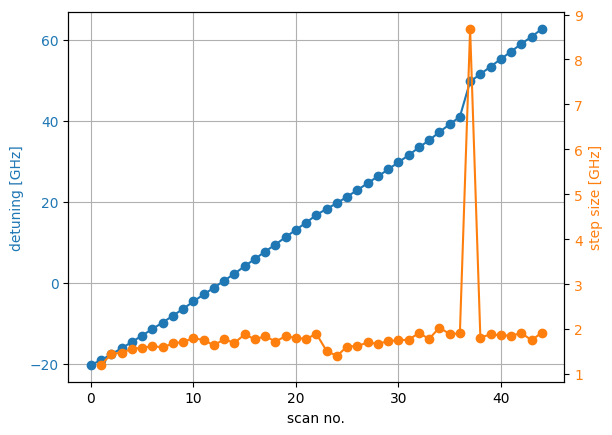

In [27]:
## check frequencies
# this only works after the very first scan. 
# if you want to detect jumps after you have done repeated scans across the jumps, go to the cells below.

#frequencies in array
fnames = []
for fname in os.listdir(path_to_data):
    condition = (('APD1' in fname) and 
        ('.dat' in fname))
    if condition:
        fnames.append(fname)

freqs = []
for fname in fnames:
    freq = re.search(r'(-?\d+\.\d+)GHz', fname).group(1)
    freq = float(freq)
    freqs.append(freq)
freqs = np.array(freqs)
freqs = np.sort(freqs) # without sorting the scnas are not ordered
xx = np.arange(0,len(freqs),1)
freqs_delta = freqs[1:] - freqs[:-1]
xx_delta = xx[1:]

# detect jumps
mean_step = np.mean(freqs_delta)
idx_jumps = np.where(abs(freqs_delta) > abs(2*mean_step))[0]

jumps = np.zeros(2)
for i in idx_jumps:
    _xx = xx_delta[i]
    jump_size = freqs_delta[i]
    jumps = np.vstack((jumps,freqs[i:i+2]))
    print('Jump detected: i=%d from %.2f to %.2fGHz (%d times mean value)'%(_xx,freqs[i],freqs[i+1],round(jump_size/mean_step)))

jumps = jumps[1:]
jumps_inv = np.flip(jumps)

# plot
color1 = 'tab:blue'
color2 = 'tab:orange'

fig, ax1 = plt.subplots()

ax1.plot(xx,freqs,marker='o',color=color1)
ax1.grid()
ax1.set_ylabel('detuning [GHz]',color=color1)
ax1.set_xlabel('scan no.')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(xx_delta,freqs_delta,marker='o',color=color2)
ax2.set_ylabel('step size [GHz]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ylims_ax2 = ax2.get_ylim()

In [16]:
## repeat confocal for detunings across the jump
experiment_name = experiment_name + '_rescan-jumps'

# decrease voltage until frequency matches
voltage = voltages[-1]
for j in range(int(np.size(jumps_inv)/2)):
    print('moving to jump number %d.'%j)
    upper_freq = jumps_inv[j,0] + mean_step/2
    lower_freq = jumps_inv[j,1] - mean_step/2
    current_wl = ws_wavemeter.get_current_wavelength()
    wavelength = (current_wl - w0) * 1e3   # to GHz
    # go to upper end of jump
    while wavelength > upper_freq:
        voltage = voltage -1
        # no negative voltages
        if voltage <= 2:
             break
        set_laser_offset(voltage)
        time.sleep(3)
        current_wl = ws_wavemeter.get_current_wavelength()
        wavelength = (current_wl - w0) * 1e3   # to GHz
        print('Going to %.2f, currently at %.2f' % (upper_freq,wavelength))
    # slowly move down
    # If a second jump happens this is not being caught. 
    # Right now I don't want to fix it and just hope it does not happen.
    i = 0
    while wavelength > lower_freq:
        ########################################################################
        # copied block that focused, did the scan and saved it.
        # turn on green
        turn_on_green()

        # go to good defect
        # do optimization once before, then always go to last opt posi
        poi_manager_logic.move_scanner(opt)

        # optimize on defect
        opt = do_optimize_and_wait()

        # turn off green
        turn_off_green()

        time.sleep(3)

        # Start scan and save data
        scanning_probe_logic.toggle_scan(True, ('x', 'y'))
        while scanning_probe_logic.module_state()=='locked':
                time.sleep(1)
        
        name, dir_ = save_scan(f"{experiment_name}_{j}_{i}_{wavelength:.2f}GHz")
        scan_names.update({wavelength: os.path.join(dir_, name)})

        print(f"Scan {i+1} for jump {j} completed for {wavelength:.2f} GHz")

        i += 1
        
        ########################################################################

        voltage = voltage - step
        if voltage <= 2:
             break
        set_laser_offset(voltage)
        time.sleep(3)
        current_wl = ws_wavemeter.get_current_wavelength()
        wavelength = (current_wl - w0) * 1e3   # to GHz

moving to jump number 0.
Going to 40.65, currently at 62.69
Going to 40.65, currently at 62.30
Going to 40.65, currently at 61.90
Going to 40.65, currently at 61.47
Going to 40.65, currently at 61.01
Going to 40.65, currently at 60.58
Going to 40.65, currently at 60.15
Going to 40.65, currently at 59.72
Going to 40.65, currently at 59.30
Going to 40.65, currently at 58.91
Going to 40.65, currently at 58.52
Going to 40.65, currently at 58.09
Going to 40.65, currently at 57.54
Going to 40.65, currently at 57.03
Going to 40.65, currently at 56.59
Going to 40.65, currently at 56.16
Going to 40.65, currently at 55.69
Going to 40.65, currently at 55.22
Going to 40.65, currently at 54.74
Going to 40.65, currently at 54.26
Going to 40.65, currently at 53.82
Going to 40.65, currently at 53.34
Going to 40.65, currently at 52.77
Going to 40.65, currently at 52.28
Going to 40.65, currently at 51.79
Going to 40.65, currently at 51.32
Going to 40.65, currently at 50.88
Going to 40.65, currently at 5

Jump detected: i=14 from 40.99 to 49.67GHz (4 times mean value)


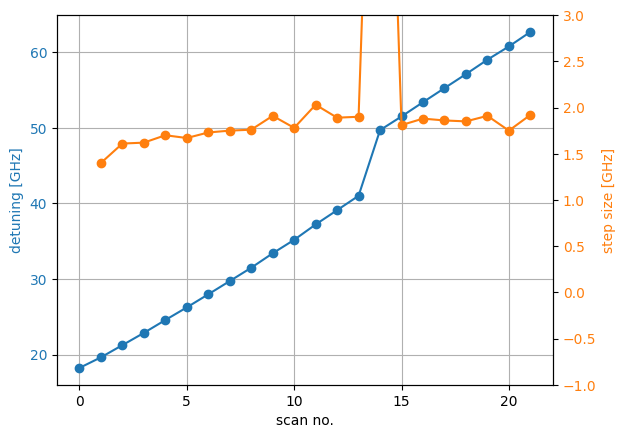

In [20]:
## plot frequencies once more
# This also prepares the cell above for repeating the scan across jumps once more.

#frequencies in array
fnames = []
for fname in os.listdir(path_to_data):
    condition = (('APD1' in fname) and 
        ('.dat' in fname))
    if condition:
        fnames.append(fname)

freqs = []
for fname in fnames:
    freq = re.search(r'(-?\d+\.\d+)GHz', fname).group(1)
    freq = float(freq)
    freqs.append(freq)
freqs = np.array(freqs)
freqs = np.sort(freqs)
xx = np.arange(0,len(freqs),1)
freqs_delta = freqs[1:] - freqs[:-1]
xx_delta = xx[1:]

# detect jumps
mean_step = np.mean(freqs_delta)
idx_jumps = np.where(freqs_delta > 2*mean_step)[0]

jumps = np.zeros(2)
for i in idx_jumps:
    _xx = xx_delta[i]
    jump_size = freqs_delta[i]
    jumps = np.vstack((jumps,freqs[i:i+2]))
    print('Jump detected: i=%d from %.2f to %.2fGHz (%d times mean value)'%(_xx,freqs[i],freqs[i+1],round(jump_size/mean_step)))

jumps = jumps[1:]
jumps_inv = np.flip(jumps)

# plot
color1 = 'tab:blue'
color2 = 'tab:orange'

fig, ax1 = plt.subplots()

ax1.plot(xx,freqs,marker='o',color=color1)
ax1.grid()
ax1.set_ylabel('detuning [GHz]',color=color1)
ax1.set_xlabel('scan no.')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(xx_delta,freqs_delta,marker='o',color=color2)
ax2.set_ylabel('step size [GHz]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
# only set ylims if defined before
ylims_ax2 = [-1,3]
try:
    ylims_ax2
except:
    pass
else:
    ax2.set_ylim(ylims_ax2)

# REscan multiple times with same frequency

In [23]:
# Parameters
w0 = 484.130 #THz
# Data structure for results
voltages = 60*np.ones(40)

In [24]:
scan_names = {}
experiment_name = "resonant-confocal_same-voltage"
# Loop through voltages
for i, voltage in enumerate(voltages):
    # Set laser frequency
    set_laser_offset(voltage)
    time.sleep(3)

    # Measure and record wavelength
    current_wl = ws_wavemeter.get_current_wavelength()
    print(f"frequency: {current_wl} THz")
    wavelength = (current_wl - w0) * 1e3   # to GHz
    print(f"detuning {wavelength} GHz")

    # turn on green
    turn_on_green()

    # go to good defect
    # do optimization once before, then always go to last opt posi
    poi_manager_logic.move_scanner(opt)

    # optimize on defect
    opt = do_optimize_and_wait()

    # turn off green
    turn_off_green()

    time.sleep(3)

    # Start scan and save data
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    
    name, dir_ = save_scan(f"{experiment_name}_{i}_{wavelength:.2f}GHz")
    scan_names.update({wavelength: os.path.join(dir_, name)})

    print(f"Scan {i+1}/{num_steps} completed for {wavelength:.2f} GHz")

with open(f"{experiment_name}.txt", 'w') as file:
    json.dump(scan_names, file, indent=4)

frequency: 484.1219359392644 THz
detuning -8.064060735591738 GHz
Scan 1/44 completed for -8.06 GHz
frequency: 484.1222146590494 THz
detuning -7.78534095059058 GHz
Scan 2/44 completed for -7.79 GHz
frequency: 484.1223072845461 THz
detuning -7.692715453913479 GHz
Scan 3/44 completed for -7.69 GHz
frequency: 484.12225308194206 THz
detuning -7.746918057932817 GHz
Scan 4/44 completed for -7.75 GHz
frequency: 484.1222482849027 THz
detuning -7.751715097299439 GHz
Scan 5/44 completed for -7.75 GHz
frequency: 484.1223052084056 THz
detuning -7.694791594417438 GHz
Scan 6/44 completed for -7.69 GHz
frequency: 484.1222457805687 THz
detuning -7.754219431319598 GHz
Scan 7/44 completed for -7.75 GHz
frequency: 484.1222575901539 THz
detuning -7.742409846116516 GHz
Scan 8/44 completed for -7.74 GHz
frequency: 484.12226491431994 THz
detuning -7.735085680053544 GHz
Scan 9/44 completed for -7.74 GHz
frequency: 484.1223073188432 THz
detuning -7.692681156811432 GHz
Scan 10/44 completed for -7.69 GHz
frequenc

# Playground

In [4]:
turn_off_green()

In [5]:
turn_on_green()

In [1]:
ws_wavemeter.get_current_wavelength()

484.0208318105391

In [14]:
del grt
try:
    grt
except:
    pass
else:
    print("yes")